<a href="https://colab.research.google.com/github/Sebacaraballo/ME239---Data-Science-for-ME/blob/main/lecture16/homework_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(lecture16:homework)=
# Homework 16

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Sebastian
+ **Last Name:** Caraballo
+ **Email:** scarabal@purdue.edu

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import numpy as np
import scipy.stats as st
import pandas as pd

/tmp/ipykernel_11380/98432282.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


# Problem 1 - Explaining the Challenger disaster
On January 28, 1986, the [Space Shuttle Challenger](https://en.wikipedia.org/wiki/Space_Shuttle_Challenger_disaster) disintegrated after 73 seconds from launch.
The failure can be traced on the rubber O-rings which were used to seal the joints of the solid rocket boosters (required to force the hot, high-pressure gases generated by the burning solid propelant through the nozzles thus producing thrust).

It turns out that the performance of the O-ring material was particularly sensitive on the external temperature during launch.
This [dataset](https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/master/homework/challenger_data.csv) contains records of different experiments with O-rings recorded at various times between 1981 and 1986.
Download the data the usual way (either put them on Google drive or run the code cell below).

In [2]:
url = 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/challenger_data.csv'
!curl -O $url

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   413  100   413    0     0   1310      0 --:--:-- --:--:-- --:--:--  1315


Even though this is a csv file, you should load it with pandas because it contains some special characters.

In [3]:
raw_data = pd.read_csv('challenger_data.csv')
raw_data

,Date,Temperature,Damage Incident
0,04/12/1981,66,0
1,11/12/1981,70,1
2,3/22/82,69,0
3,6/27/82,80,NaN
4,01/11/1982,68,0
5,04/04/1983,67,0
6,6/18/83,72,0
7,8/30/83,73,0
8,11/28/83,70,0
9,02/03/1984,57,1


The first column is the date of the record. The second column is the external temperature of that day in degrees F.
The third column labeled ``Damage Incident`` is has a binary coding (0=no damage, 1=damage).
The very last row is the day of the Challenger accident.

We are going to use the first 23 rows to solve a binary classification problem that will give us the probability of an accident conditioned on the observed external temperature in degrees F. Before we proceed to the analysis of the data, let's clean the data up.

First, we drop all the bad records:

In [4]:
clean_data = raw_data.dropna()

We also don't need the last record. Just remember that the temperature the day of the Challenger accident was 31 degrees F.
Remove the last record from the dataframe.

In [5]:
clean_data = clean_data.iloc[:-1]
clean_data

,Date,Temperature,Damage Incident
0,04/12/1981,66,0
1,11/12/1981,70,1
2,3/22/82,69,0
4,01/11/1982,68,0
5,04/04/1983,67,0
6,6/18/83,72,0
7,8/30/83,73,0
8,11/28/83,70,0
9,02/03/1984,57,1
10,04/06/1984,63,1


Let's extract the features and the labels:

In [6]:
x = clean_data['Temperature'].values
x

array([66, 70, 69, 68, 67, 72, 73, 70, 57, 63, 70, 78, 67, 53, 67, 75, 70,
       81, 76, 79, 75, 76, 58])

In [7]:
y = clean_data['Damage Incident'].values.astype(int)
y

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1])

## Part A - Perform logistic regression

Perform logistic regression between the temperature ($x$) and the damage label ($y$).
Do not bother doing a validation because there are not a lot of data.
Just use a very simple model so that you don't overfit.

**Answer:**
This is one of the cases, where we don't have a lot of data.
So we are going to use everything for training.
To avoid overfitting, we will use the simplest possible model.
The model is:
$$
p(y|x,w) = \operatorname{sigm}(w_0 + w_1 x),
$$
where $w_0$ and $w_1$ are parameters to be determined by data.

In [8]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Reshape x for sklearn (needs 2D array)
X = x.reshape(-1, 1)

# Fit logistic regression - C=1e10 means very little regularization
# (we want the data to speak, not the prior, but we keep model simple with degree 1)
model = LogisticRegression(C=1e10)
model.fit(X, y)

LogisticRegression(C=10000000000.0)

This is it. Let's take a look at the parameters that that were found:

In [9]:
print(f'w0 (intercept) = {model.intercept_[0]:.4f}')
print(f'w1 (temperature coefficient) = {model.coef_[0][0]:.4f}')

w0 (intercept) = 15.0429
w1 (temperature coefficient) = -0.2322


We observe a negative correlation between temperature and damage. Damage becomes more probable as temperature decreases.

## Part B - Plot the probability of damage as a function of temperature
Plot the probability of damage as a function of temperature.

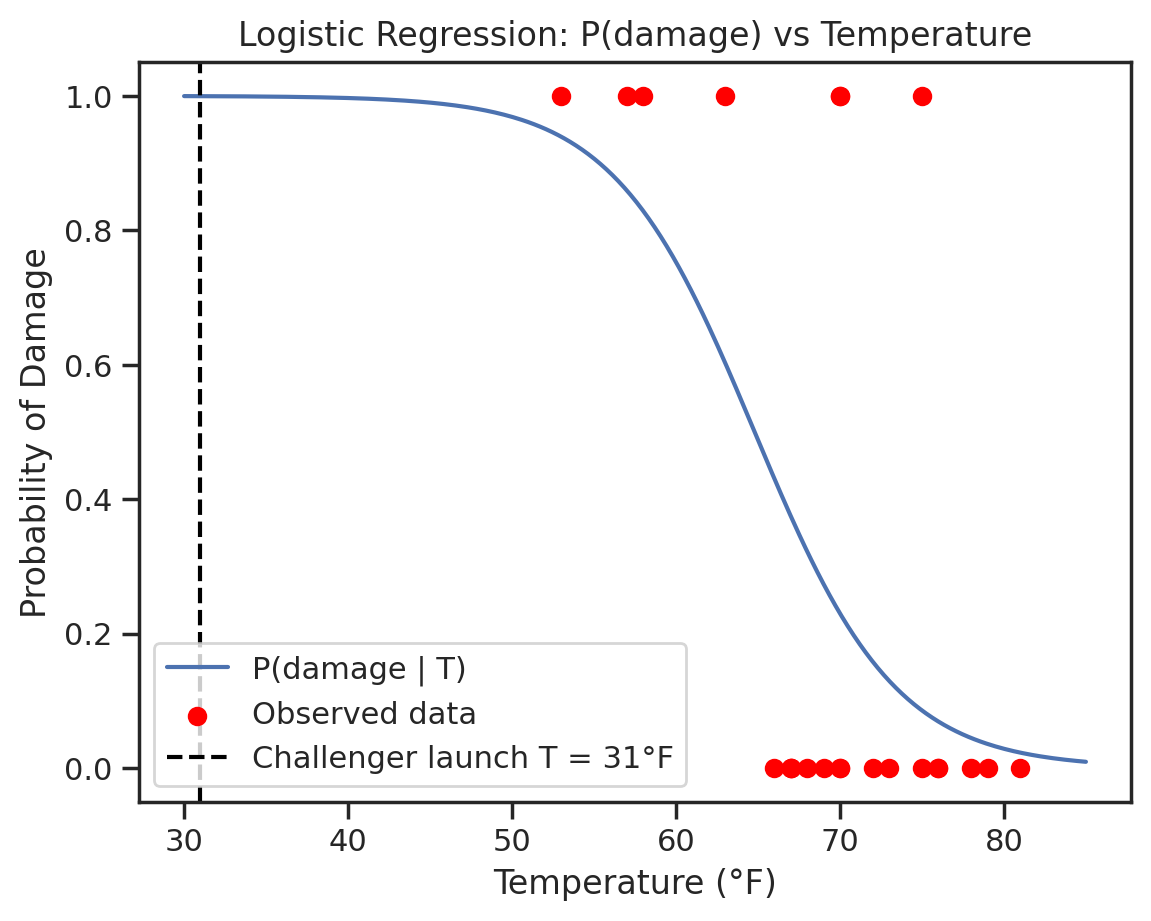

In [10]:
T_range = np.linspace(30, 85, 300).reshape(-1, 1)
p_damage = model.predict_proba(T_range)[:, 1]

fig, ax = plt.subplots()
ax.plot(T_range, p_damage, label='P(damage | T)')
ax.scatter(x, y, color='red', zorder=5, label='Observed data')
ax.axvline(31, color='black', linestyle='--', label='Challenger launch T = 31°F')
ax.set_xlabel('Temperature (°F)')
ax.set_ylabel('Probability of Damage')
ax.set_title('Logistic Regression: P(damage) vs Temperature')
ax.legend();

## Part C - Decide whether or not to launch

The temperature the day of the Challenger accident was 31 degrees F.
Would you go ahead with the launch or not?
Hint: Start by calculating the probability of damage at 31 degrees F.

In [11]:
T_challenger = np.array([[31]])
p_damage_challenger = model.predict_proba(T_challenger)[0, 1]
print(f'P(damage | T=31°F) = {p_damage_challenger:.4f}')

P(damage | T=31°F) = 0.9996


Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_16.ipynb'